# Evaluate illumination type and segmentation performance prior to running metrics

**Context**: Usually in standard widefield microscopy (like with the Phenix microscope), we see illumination issues in the FOVs as a vignetting effect. This is where the center of the FOV has the highest intensity that fades and becomes dimmer in a circular shape, where the edges are less intense. But, other microscopes have shown there is sometimes a non-standard uneven illumination across the image (e.g., one side is brighter than the other, etc).

**In this notebook, we are assessing two datasets to optimize segmentation of foreground and background for metrics and determine what type of illumination issue is occurring per channel.**

In [ ]:
from pathlib import Path

import skimage.io

from miice.evaluate_parameters import evaluate_segmentation, visualize_illumination


## Dataset #1: NF1

In [2]:
# Set directory for example images input
raw_data_dir = Path("../../../testing/nf1_small_example/Plate_1").resolve(strict=True)

# This dataset has three channels: DAPI, RFP, and GFP
channels = ["DAPI", "RFP", "GFP"]


def example_per_channel(directory: Path) -> dict[str, Path]:
    """Pick one reproducible example image per channel from `directory` (matches .tif and .tiff)."""
    return {
        channel: min(
            (
                p
                for ext in ("tif", "tiff")
                for p in directory.glob(f"*{channel}*.{ext}")
            ),
            key=lambda p: p.name,
        )
        for channel in channels
    }


raw_examples = example_per_channel(raw_data_dir)


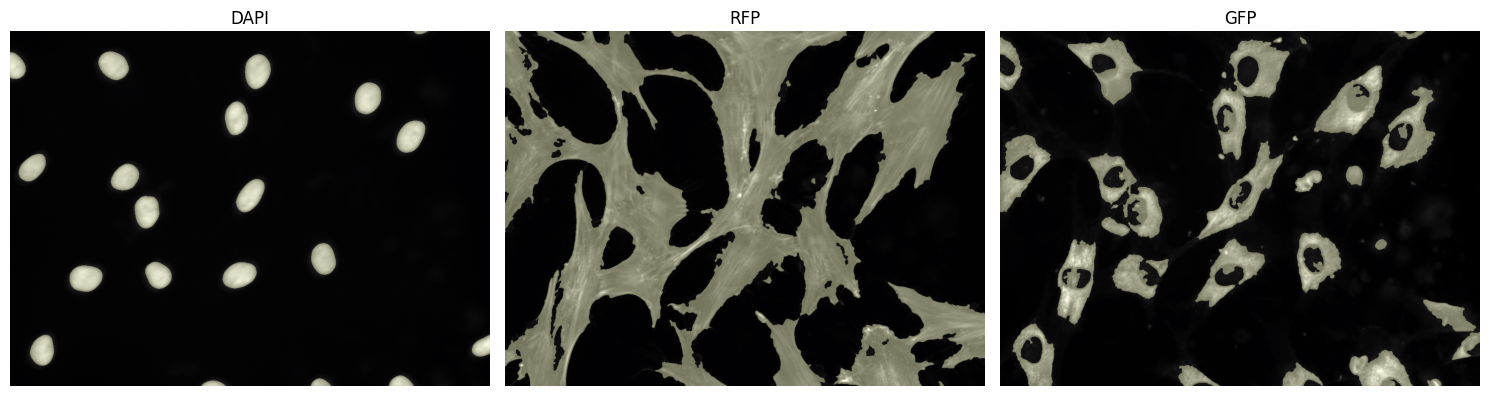

In [3]:
# Evaluate segmentation on one example image per channel (raw)
raw_masks = evaluate_segmentation(raw_examples)


Segmentation of foreground versus background look good across all channels, with some minor issues in GFP but this should not influence the metrics.

### Visualize illumination pattern per channel (raw)

Channel: DAPI


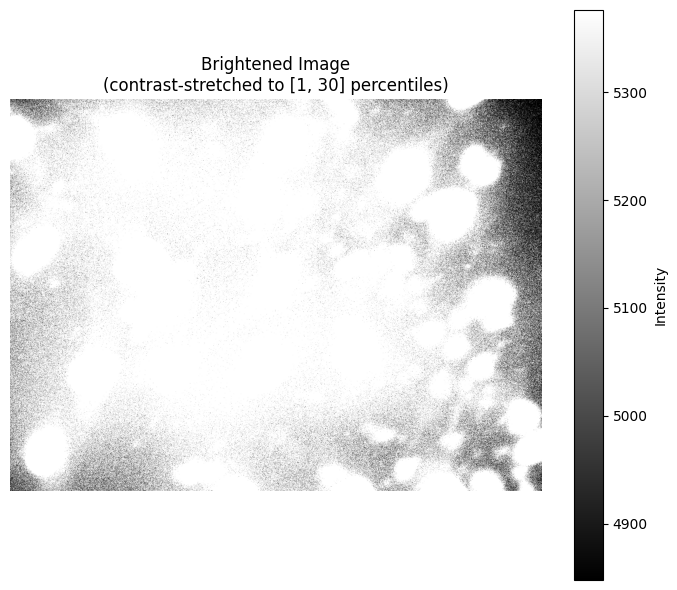

Channel: RFP


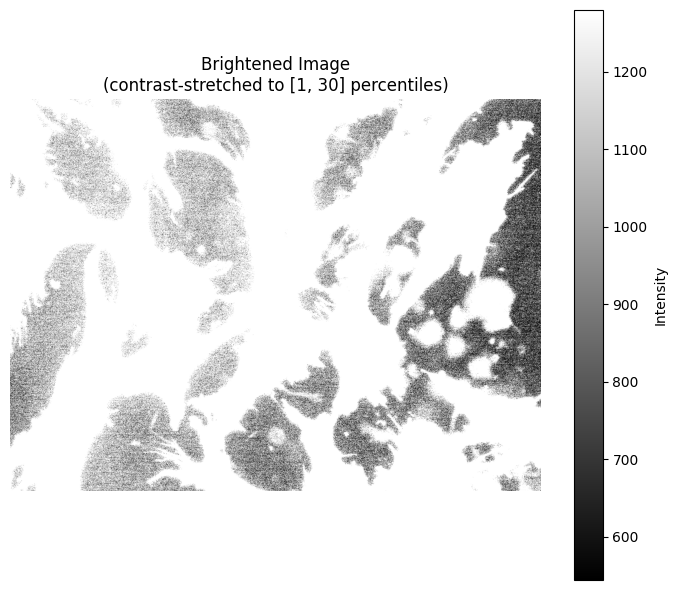

Channel: GFP


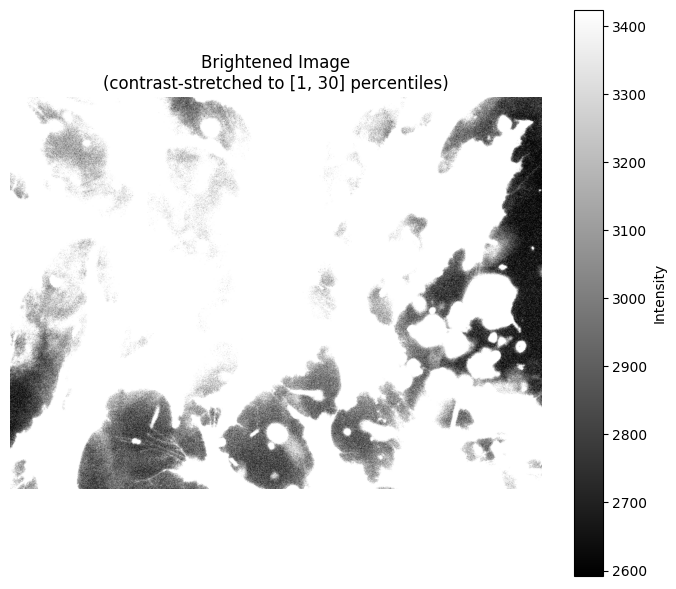

In [4]:
for channel, image_path in raw_examples.items():
    print(f"Channel: {channel}")
    image = skimage.io.imread(image_path)
    visualize_illumination(image, clip_percentiles=[1,30])


Visually, we can see these images do not have the standard vignetting. For most, one side is slightly brighter than the other.

## Dataset #2: PCCMA

In [5]:
# Set directory for example images input
raw_data_dir = Path("../../../testing/phenix_u2os_example/images").resolve(strict=True)

# This dataset has five Cell Painting channels:
channels = ["ch2", "ch3", "ch4", "ch5", "ch6"]

def example_per_channel(directory: Path) -> dict[str, Path]:
    """Pick one reproducible example image per channel from `directory` (matches .tif and .tiff)."""
    return {
        channel: min(
            (
                p
                for ext in ("tif", "tiff")
                for p in directory.glob(f"*{channel}*.{ext}")
            ),
            key=lambda p: p.name,
        )
        for channel in channels
    }


raw_examples = example_per_channel(raw_data_dir)


In [6]:
raw_examples


{'ch2': PosixPath('/home/jenna/MIICE/testing/phenix_u2os_example/images/r15c03f01p01-ch2sk1fk1fl1.tiff'),
 'ch3': PosixPath('/home/jenna/MIICE/testing/phenix_u2os_example/images/r15c03f01p01-ch3sk1fk1fl1.tiff'),
 'ch4': PosixPath('/home/jenna/MIICE/testing/phenix_u2os_example/images/r15c03f01p01-ch4sk1fk1fl1.tiff'),
 'ch5': PosixPath('/home/jenna/MIICE/testing/phenix_u2os_example/images/r15c03f01p01-ch5sk1fk1fl1.tiff'),
 'ch6': PosixPath('/home/jenna/MIICE/testing/phenix_u2os_example/images/r15c03f01p01-ch6sk1fk1fl1.tiff')}

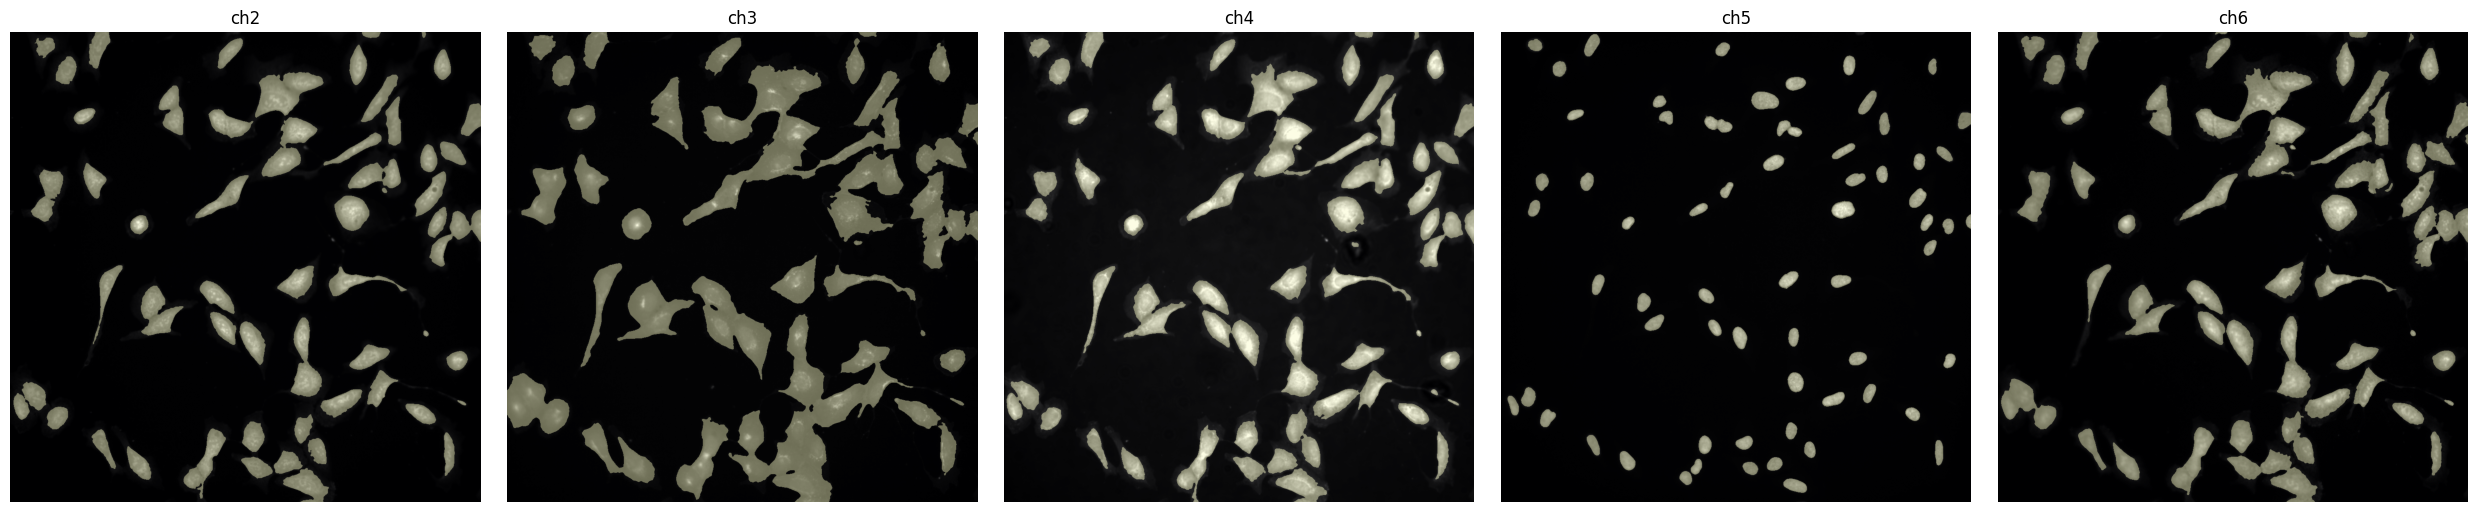

In [7]:
# Evaluate segmentation on one example image per channel (raw)
raw_masks = evaluate_segmentation(raw_examples)


The segmentation looks fairly good across channels, maybe some cells here are there are not as accurate. Overall, the foreground versus background separate looks pretty good enough!

### Visualize illumination pattern per channel (raw)

Channel: ch2


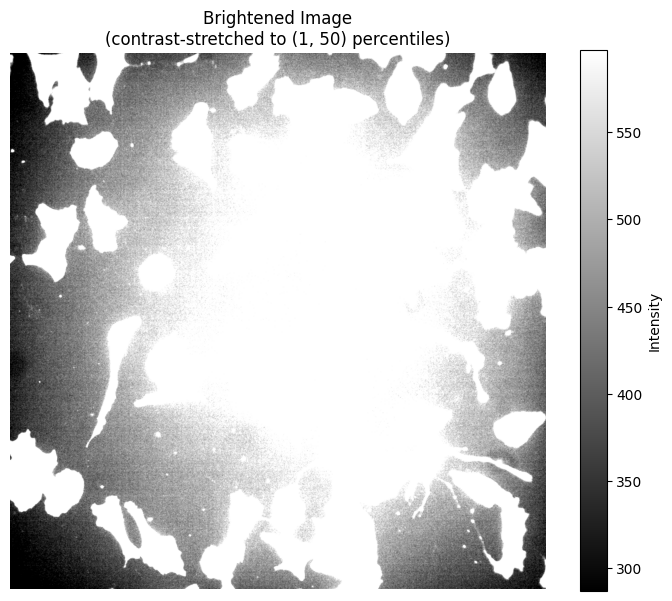

Channel: ch3


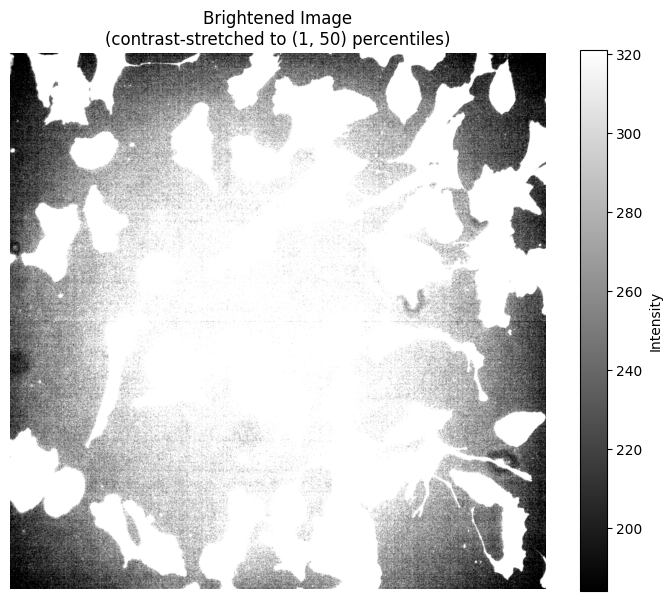

Channel: ch4


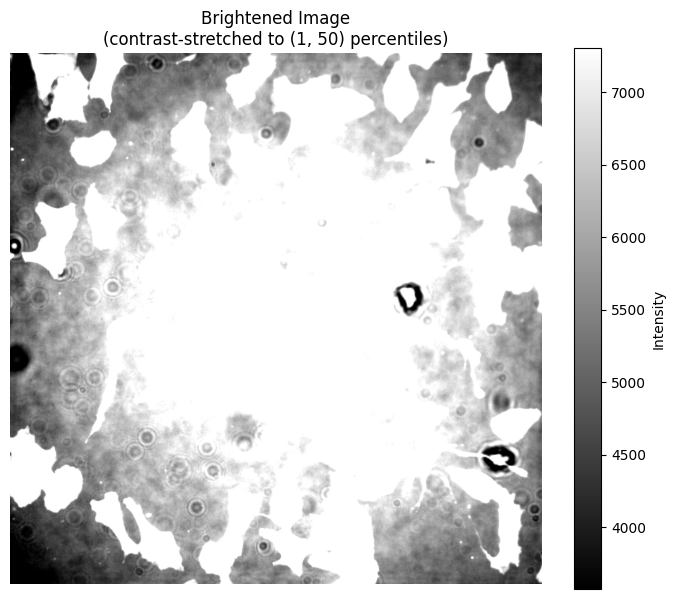

Channel: ch5


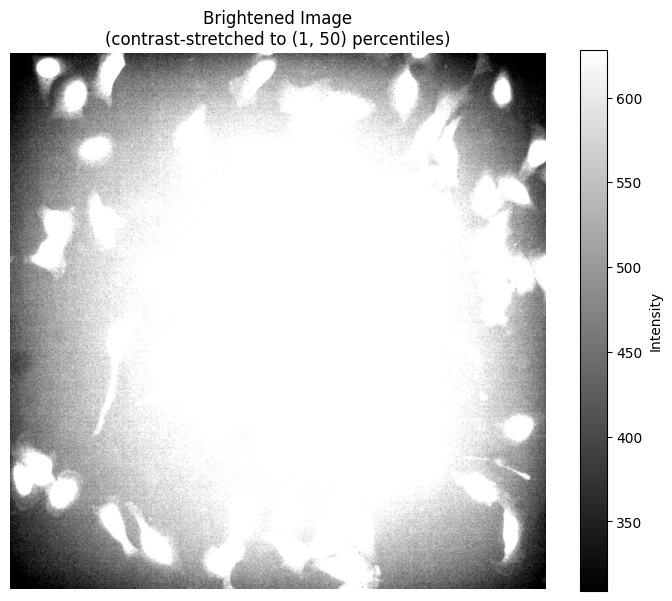

Channel: ch6


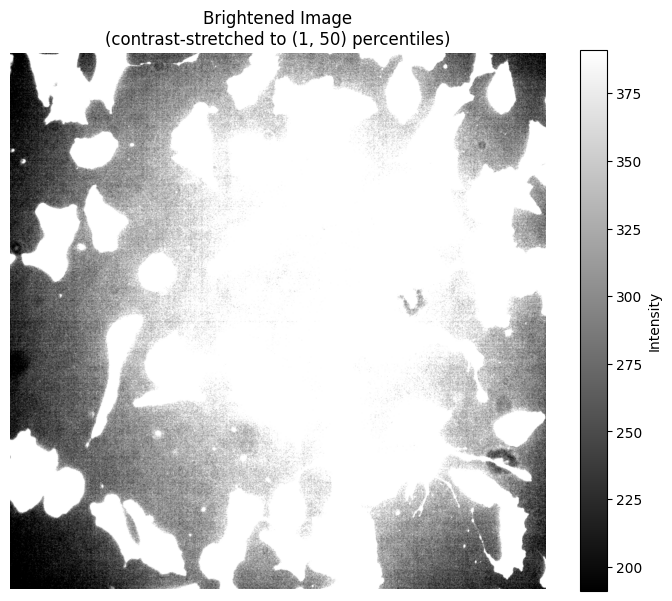

In [8]:
for channel, image_path in raw_examples.items():
    print(f"Channel: {channel}")
    image = skimage.io.imread(image_path)
    visualize_illumination(image)


This dataset shows consistent vignetting across all channels.